In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/netflix_titles.csv')

In [5]:
df.isnull().shape

(8807, 12)

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [36]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [41]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [42]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [43]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

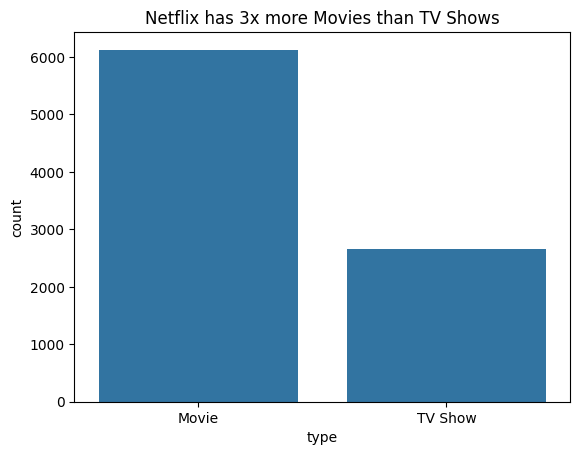

In [73]:
# Netflix มี Movie กับ TV Show สัดส่วนเท่าไหร่
df['type'].value_counts()

sns.countplot(data=df, x='type')
plt.title('Netflix has 3x more Movies than TV Shows')
plt.show()

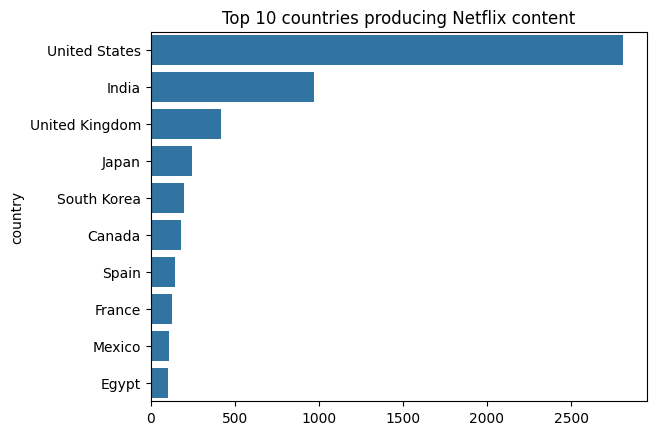

In [62]:
top10 = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

sns.barplot(x=top10.values, y=top10.index)
plt.title('Top 10 countries producing Netflix content')
plt.show()

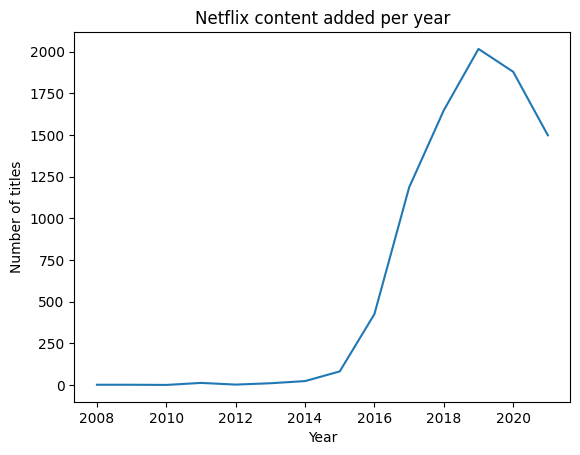

In [72]:
# content ถูกเพิ่มเข้า Netflix มากที่สุดปีไหน
df['year_added'] = pd.to_datetime(df['date_added'], format='mixed').dt.year
year_counts = df['year_added'].value_counts().sort_index()

sns.lineplot(x=year_counts.index, y=year_counts.values)
plt.title('Netflix content added per year')
plt.xlabel('Year')
plt.ylabel('Number of titles')
plt.show()

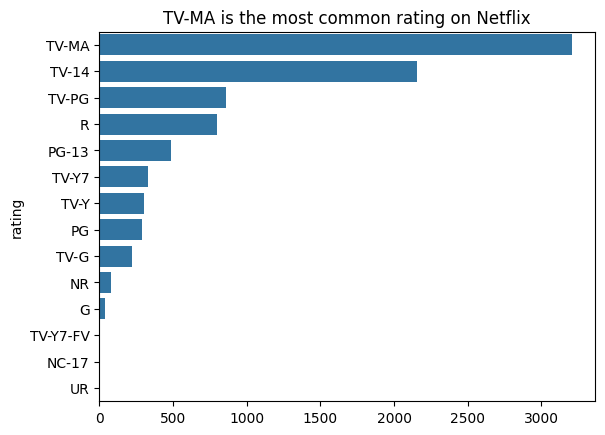

In [71]:
# rating ที่พบบ่อยที่สุดคืออะไร
rating = df['rating'].value_counts()

sns.barplot(x=rating.values, y=rating.index)
plt.title('TV-MA is the most common rating on Netflix')
plt.show()

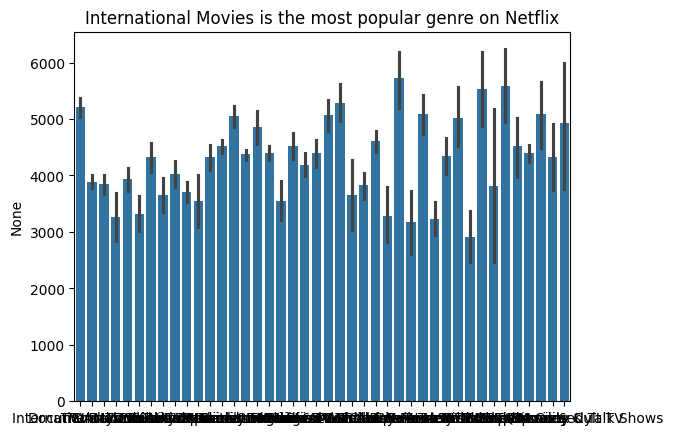

In [ ]:
# หมวดหมู่ (list_in) ที่ได้รับความนิยมมากที่สุด
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts()

sns.barplot(x=genres.values, y=genres.index)
plt.title('International Movies is the most popular genre on Netflix')
plt.show()